In [1]:
# =========================================================
# ANÁLISIS DE MOVILIDAD Y PERCEPCIÓN URBANA
# ENCUESTA DE CALIDAD DE VIDA - HUILA
# =========================================================

# =========================================================
# 1. IMPORTAR LIBRERÍAS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.getcwd()


'/content'

In [2]:
sns.set(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

In [3]:
df = pd.read_excel("BASE_MOVILIDAD_COD.xlsx")

In [4]:
print("\nPRIMERAS FILAS:")
print(df.head())

print("\nDIMENSIONES:")
print(df.shape)

print("\nCOLUMNAS:")
print(df.columns)


PRIMERAS FILAS:
  Municipio   Año  Sexo  Edad  Nivel socioeconomico  Percepcion  \
0    Garzon  2021     0    31                     1           1   
1    Garzon  2021     1    21                     0           0   
2    Garzon  2021     1    27                     1           0   
3    Garzon  2021     1    19                     1           0   
4    Garzon  2021     1    22                     0           1   

   Seguridad en el municipio  Vias Transporte  Bus  Taxi  Vehiculo  Moto  \
0                          1     0  Bicicleta  NaN   NaN       NaN   NaN   
1                          0     0       Moto  NaN   NaN       NaN   1.0   
2                          0     1      A pie  NaN   NaN       NaN   NaN   
3                          0     1      A pie  1.0   1.0       1.0   1.0   
4                          0     1       Moto  NaN   NaN       NaN   1.0   

   A pie  Bicicleta  Otro transporte  
0    NaN        1.0              NaN  
1    NaN        NaN              NaN  
2    1

In [5]:
# 5. INFORMACIÓN GENERAL
# =========================================================

print("\n=================================================")
print("INFORMACIÓN GENERAL")
print("=================================================\n")

print(df.info())


INFORMACIÓN GENERAL

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5912 entries, 0 to 5911
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Municipio                  5912 non-null   object 
 1   Año                        5912 non-null   int64  
 2   Sexo                       5912 non-null   int64  
 3   Edad                       5912 non-null   int64  
 4   Nivel socioeconomico       5912 non-null   int64  
 5   Percepcion                 5912 non-null   int64  
 6   Seguridad en el municipio  5912 non-null   int64  
 7   Vias                       5912 non-null   int64  
 8   Transporte                 5912 non-null   object 
 9   Bus                        2375 non-null   float64
 10  Taxi                       1978 non-null   float64
 11  Vehiculo                   2125 non-null   float64
 12  Moto                       4059 non-null   float64
 13  A pie                     

In [6]:
# SEXO
# ---------------------------------------------------------

df["Sexo"] = df["Sexo"].replace({
    0: "Masculino",
    1: "Femenino"
})

# ---------------------------------------------------------
# NIVEL SOCIOECONÓMICO
# ---------------------------------------------------------

df["Nivel socioeconomico"] = df["Nivel socioeconomico"].replace({
    0: "Bajo",
    1: "Medio",
    2: "Alto"
})

In [7]:
# PERCEPCIÓN DEL MUNICIPIO
# ---------------------------------------------------------

df["Percepcion"] = df["Percepcion"].replace({
    0: "Mal camino",
    1: "Buen camino"
})


In [8]:
# SEGURIDAD
# ---------------------------------------------------------

df["Seguridad en el municipio"] = df["Seguridad en el municipio"].replace({
    0: "Inseguro",
    1: "Seguro"
})

In [9]:
# VÍAS
# ---------------------------------------------------------

df["Vias"] = df["Vias"].replace({
    0: "Insatisfecho",
    1: "Satisfecho"
})

In [10]:
variables_transporte = [
    "Bus",
    "Taxi",
    "Vehiculo",
    "Moto",
    "A pie",
    "Bicicleta"
]

for var in variables_transporte:

    df[var] = df[var].replace({
        0: "Insatisfecho",
        1: "Satisfecho"
    })

In [11]:
# 8. NOTA METODOLÓGICA SOBRE LOS NA
# =========================================================

print("\n=================================================")
print("TRATAMIENTO DE LOS NA")
print("=================================================\n")

print("""
Las variables de satisfacción con medios de transporte
(Bus, Taxi, Vehiculo, Moto, A pie y Bicicleta)
presentan NA estructurales.

Estos NA corresponden principalmente a medios
de transporte que no aplican para algunos encuestados,
es decir, situaciones en las que la persona
no usa o no calificó determinado medio.

Por tanto, los porcentajes de satisfacción
se calcularon usando como denominador
únicamente las personas que sí evaluaron
cada medio de transporte, excluyendo
los NA estructurales.

Los datos perdidos reales fueron eliminados
previamente durante la limpieza de datos en Excel.
""")


TRATAMIENTO DE LOS NA


Las variables de satisfacción con medios de transporte
(Bus, Taxi, Vehiculo, Moto, A pie y Bicicleta)
presentan NA estructurales.

Estos NA corresponden principalmente a medios
de transporte que no aplican para algunos encuestados,
es decir, situaciones en las que la persona
no usa o no calificó determinado medio.

Por tanto, los porcentajes de satisfacción
se calcularon usando como denominador
únicamente las personas que sí evaluaron
cada medio de transporte, excluyendo
los NA estructurales.

Los datos perdidos reales fueron eliminados
previamente durante la limpieza de datos en Excel.



In [12]:
# 9. TAMAÑO MUESTRAL POR MUNICIPIO
# =========================================================

print("\n=================================================")
print("TAMAÑO MUESTRAL POR MUNICIPIO")
print("=================================================\n")

n_municipio = df["Municipio"].value_counts()

print(n_municipio)



TAMAÑO MUESTRAL POR MUNICIPIO

Municipio
Garzon      3413
Neiva       2298
Pitalito     201
Name: count, dtype: int64


In [13]:
# 10. TAMAÑO MUESTRAL POR NIVEL SOCIOECONÓMICO
# =========================================================

print("\n=================================================")
print("TAMAÑO MUESTRAL POR NIVEL SOCIOECONÓMICO")
print("=================================================\n")

n_nivel = df["Nivel socioeconomico"].value_counts()

print(n_nivel)


TAMAÑO MUESTRAL POR NIVEL SOCIOECONÓMICO

Nivel socioeconomico
Medio    3498
Bajo     2254
Alto      160
Name: count, dtype: int64


In [14]:
# 11. DISTRIBUCIÓN GENERAL DEL TRANSPORTE
# =========================================================

print("\n=================================================")
print("DISTRIBUCIÓN GENERAL DEL TRANSPORTE")
print("=================================================\n")

frecuencia_transporte = df["Transporte"].value_counts()

porcentaje_transporte = round(
    df["Transporte"].value_counts(normalize=True) * 100,
    2
)

tabla_transporte = pd.DataFrame({
    "Frecuencia": frecuencia_transporte,
    "Porcentaje": porcentaje_transporte
})

print(tabla_transporte)


DISTRIBUCIÓN GENERAL DEL TRANSPORTE

            Frecuencia  Porcentaje
Transporte                        
Moto              3076       52.03
A pie             1147       19.40
Bus                815       13.79
Vehiculo           570        9.64
Taxi               167        2.82
Bicicleta          137        2.32


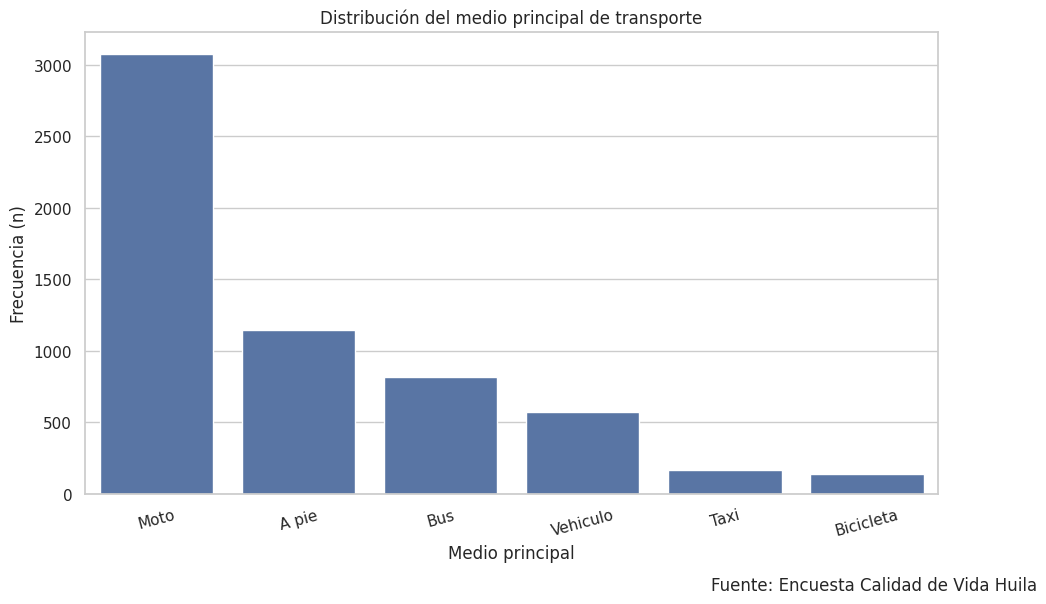


TRANSPORTE POR MUNICIPIO

Transporte  A pie  Bicicleta  Bus  Moto  Taxi  Vehiculo
Municipio                                              
Garzon        789         45  178  2092    69       240
Neiva         272         78  564   984    70       330
Pitalito       86         14   73     0    28         0

PORCENTAJES POR MUNICIPIO

Transporte  A pie  Bicicleta    Bus   Moto   Taxi  Vehiculo
Municipio                                                  
Garzon      23.12       1.32   5.22  61.30   2.02      7.03
Neiva       11.84       3.39  24.54  42.82   3.05     14.36
Pitalito    42.79       6.97  36.32   0.00  13.93      0.00


In [16]:
# =========================================================
# 12. GRÁFICO GENERAL DE TRANSPORTE
# =========================================================

plt.figure(figsize=(11,6))

sns.countplot(
    data=df,
    x="Transporte",
    order=df["Transporte"].value_counts().index
)

plt.title("Distribución del medio principal de transporte")
plt.xlabel("Medio principal")
plt.ylabel("Frecuencia (n)")

plt.xticks(rotation=15)

plt.figtext(
    0.99,
    -0.05,
    "Fuente: Encuesta Calidad de Vida Huila",
    horizontalalignment="right"
)

plt.show()

# =========================================================
# 13. TRANSPORTE POR MUNICIPIO
# =========================================================

print("\n=================================================")
print("TRANSPORTE POR MUNICIPIO")
print("=================================================\n")

tabla_municipio = pd.crosstab(
    df["Municipio"],
    df["Transporte"]
)

print(tabla_municipio)

print("\n=================================================")
print("PORCENTAJES POR MUNICIPIO")
print("=================================================\n")

tabla_municipio_pct = round(
    pd.crosstab(
        df["Municipio"],
        df["Transporte"],
        normalize="index"
    ) * 100,
    2
)

print(tabla_municipio_pct)

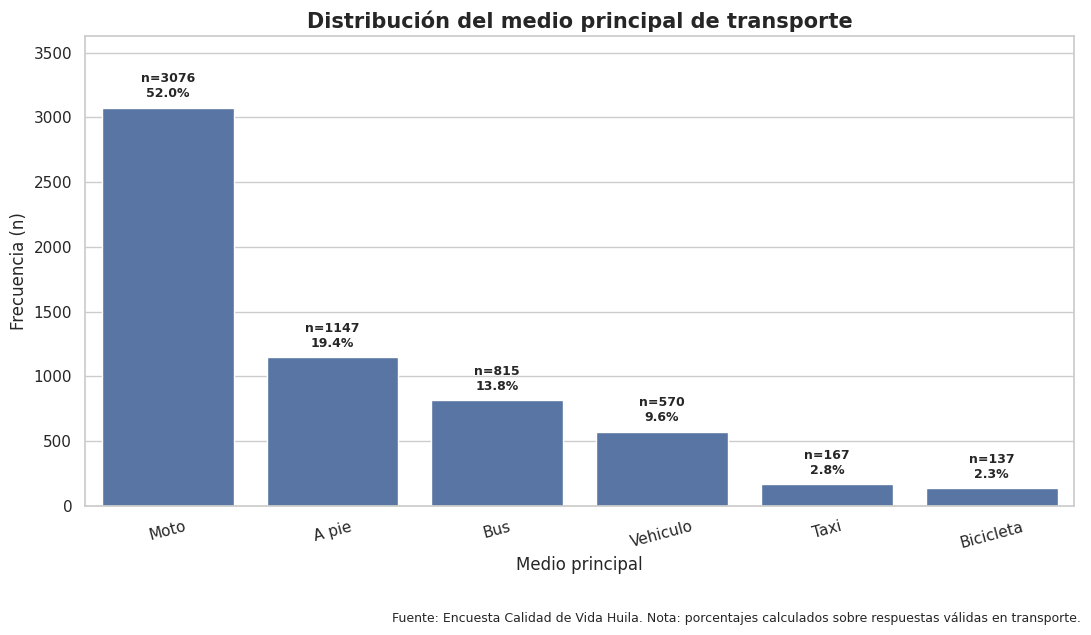


TRANSPORTE POR MUNICIPIO

Transporte  A pie  Bicicleta  Bus  Moto  Taxi  Vehiculo
Municipio                                              
Garzon        789         45  178  2092    69       240
Neiva         272         78  564   984    70       330
Pitalito       86         14   73     0    28         0

PORCENTAJES POR MUNICIPIO

Transporte  A pie  Bicicleta    Bus   Moto   Taxi  Vehiculo
Municipio                                                  
Garzon      23.12       1.32   5.22  61.30   2.02      7.03
Neiva       11.84       3.39  24.54  42.82   3.05     14.36
Pitalito    42.79       6.97  36.32   0.00  13.93      0.00


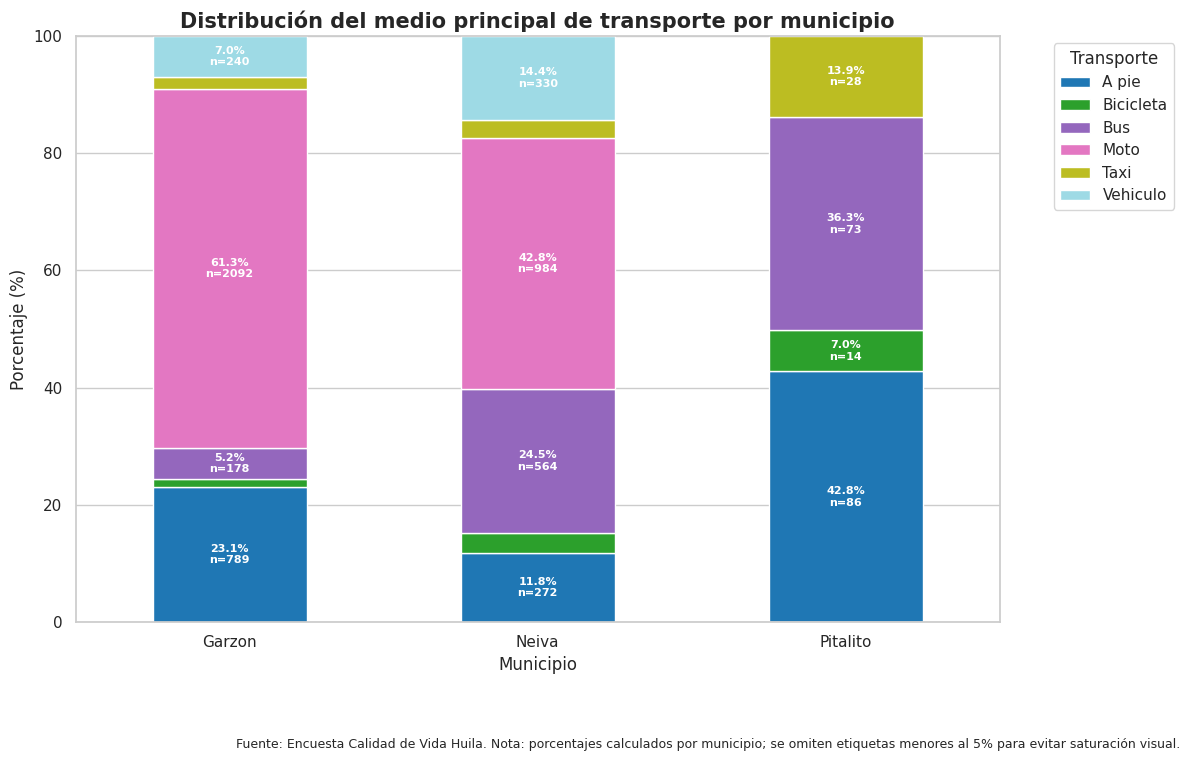

In [21]:
# =========================================================
# 12. GRÁFICO GENERAL DE TRANSPORTE CON n Y %
# =========================================================

plt.figure(figsize=(11,6))

orden_transporte = df["Transporte"].value_counts().index
total_transporte = df["Transporte"].notna().sum()

ax = sns.countplot(
    data=df,
    x="Transporte",
    order=orden_transporte
)

plt.title("Distribución del medio principal de transporte", fontsize=15, fontweight="bold")
plt.xlabel("Medio principal")
plt.ylabel("Frecuencia (n)")
plt.xticks(rotation=15)

# Agregar etiquetas con n y %
for barra in ax.patches:
    n = barra.get_height()
    porcentaje = (n / total_transporte) * 100 if total_transporte > 0 else 0

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        n + (total_transporte * 0.01),
        f"n={int(n)}\n{porcentaje:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Ajustar límite superior para que no se corten las etiquetas
max_n = df["Transporte"].value_counts().max()
plt.ylim(0, max_n * 1.18)

plt.figtext(
    0.99,
    -0.05,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: porcentajes calculados sobre respuestas válidas en transporte.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.show()


# =========================================================
# 13. TRANSPORTE POR MUNICIPIO CON n Y %
# =========================================================

print("\n=================================================")
print("TRANSPORTE POR MUNICIPIO")
print("=================================================\n")

tabla_municipio = pd.crosstab(
    df["Municipio"],
    df["Transporte"]
)

print(tabla_municipio)

print("\n=================================================")
print("PORCENTAJES POR MUNICIPIO")
print("=================================================\n")

tabla_municipio_pct = round(
    pd.crosstab(
        df["Municipio"],
        df["Transporte"],
        normalize="index"
    ) * 100,
    2
)

print(tabla_municipio_pct)


# =========================================================
# GRÁFICO TRANSPORTE POR MUNICIPIO CON n Y %
# =========================================================

ax = tabla_municipio_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7),
    colormap="tab20"
)

plt.title("Distribución del medio principal de transporte por municipio", fontsize=15, fontweight="bold")
plt.xlabel("Municipio")
plt.ylabel("Porcentaje (%)")
plt.ylim(0,100)
plt.xticks(rotation=0)
plt.legend(title="Transporte", bbox_to_anchor=(1.05, 1), loc="upper left")

# Agregar etiquetas dentro de cada segmento: % y n
for contenedor, transporte in zip(ax.containers, tabla_municipio_pct.columns):

    etiquetas = []

    for i, porcentaje in enumerate(contenedor.datavalues):
        municipio = tabla_municipio_pct.index[i]
        n = tabla_municipio.loc[municipio, transporte]

        if porcentaje < 5:
            etiquetas.append("")
        else:
            etiquetas.append(f"{porcentaje:.1f}%\nn={int(n)}")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8,
        color="white",
        fontweight="bold"
    )

plt.figtext(
    0.99,
    -0.08,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: porcentajes calculados por municipio; se omiten etiquetas menores al 5% para evitar saturación visual.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.show()

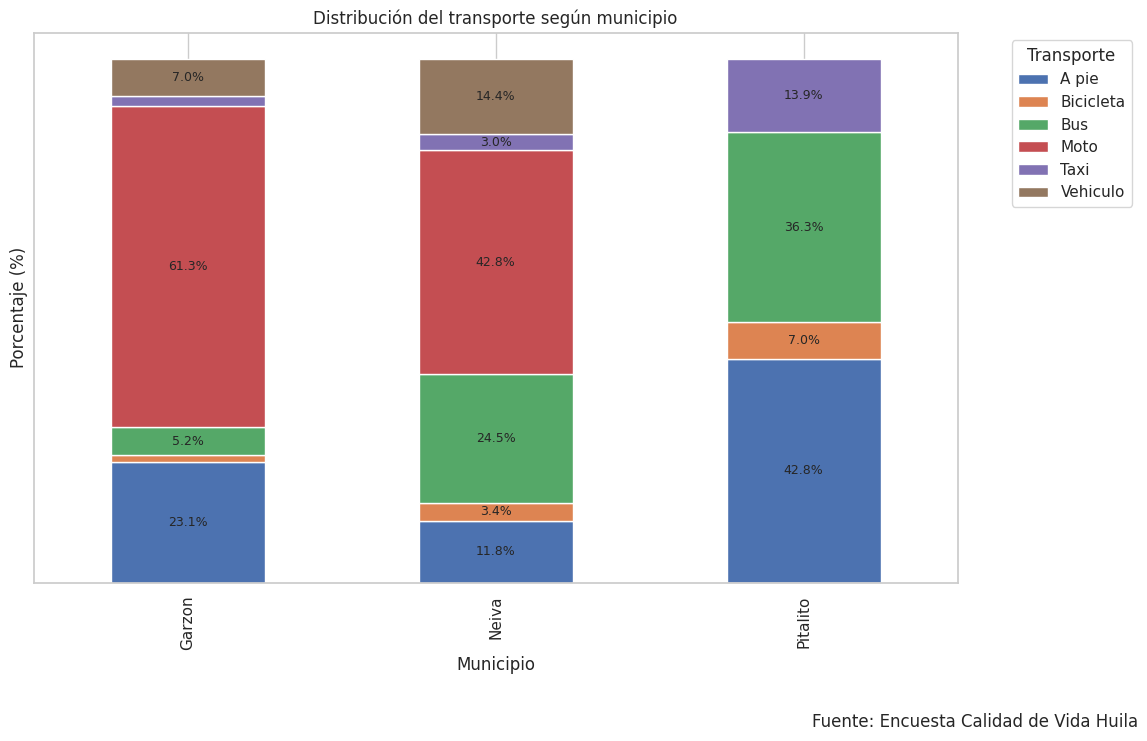

In [17]:
# =========================================================
# 14. GRÁFICO TRANSPORTE X MUNICIPIO
# =========================================================

ax = tabla_municipio_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7)
)

plt.title("Distribución del transporte según municipio")
plt.xlabel("Municipio")
plt.ylabel("Porcentaje (%)")

plt.legend(
    title="Transporte",
    bbox_to_anchor=(1.05,1)
)

# =========================================================
# AGREGAR PORCENTAJES DENTRO DE LAS BARRAS
# =========================================================

for container in ax.containers:

    labels = []

    for v in container.datavalues:

        if v > 3:
            labels.append(f"{v:.1f}%")
        else:
            labels.append("")

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

# =========================================================
# FUENTE
# =========================================================

plt.figtext(
    0.99,
    -0.05,
    "Fuente: Encuesta Calidad de Vida Huila",
    horizontalalignment="right"
)

plt.tight_layout()
plt.yticks([])
plt.show()


ESTRUCTURA DEL PANEL POR MUNICIPIO Y AÑO

  Municipio   Año     n
0    Garzon  2021   422
1    Garzon  2022  1202
2    Garzon  2023  1273
3    Garzon  2024   409
4    Garzon  2025   107
5     Neiva  2024  1149
6     Neiva  2025  1149
7  Pitalito  2025   201

Nota metodológica:
El panel es desbalanceado. Para el tema de movilidad:
- Garzón permite análisis temporal 2021-2025.
- Neiva solo permite comparación 2024-2025.
- Pitalito solo tiene información para 2025.
- Las comparaciones entre municipios se hacen únicamente para 2025.


SATISFACCIÓN GENERAL POR MEDIO DE TRANSPORTE

  Medio de transporte  n válido  Satisfechos  Insatisfechos  % satisfecho  \
0                 Bus      2375         1205           1170         50.74   
1                Taxi      1978         1044            934         52.78   
2            Vehiculo      2125         1564            561         73.60   
3                Moto      4059         3513            546         86.55   
4               A pie      2615

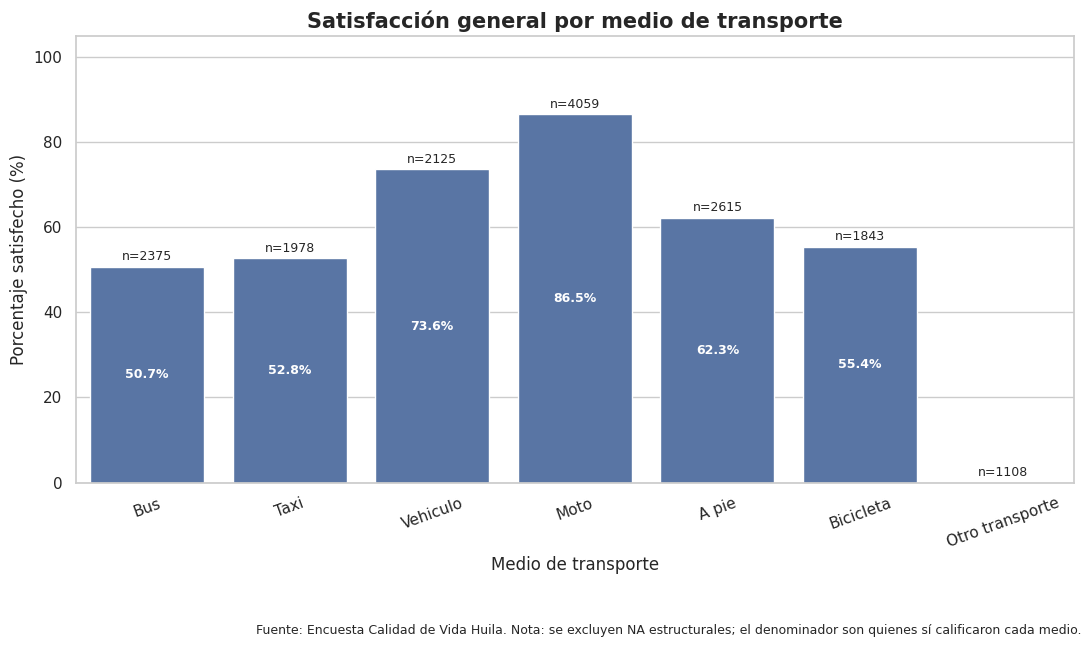


MEDIO PRINCIPAL DE TRANSPORTE POR MUNICIPIO, 2025 - n

Transporte  A pie  Bicicleta  Bus  Moto  Taxi  Vehiculo
Municipio                                              
Garzon         68          3   28     0     8         0
Neiva         136         39  282   492    35       165
Pitalito       86         14   73     0    28         0

MEDIO PRINCIPAL DE TRANSPORTE POR MUNICIPIO, 2025 - %

Transporte  A pie  Bicicleta    Bus   Moto   Taxi  Vehiculo
Municipio                                                  
Garzon      63.55       2.80  26.17   0.00   7.48      0.00
Neiva       11.84       3.39  24.54  42.82   3.05     14.36
Pitalito    42.79       6.97  36.32   0.00  13.93      0.00


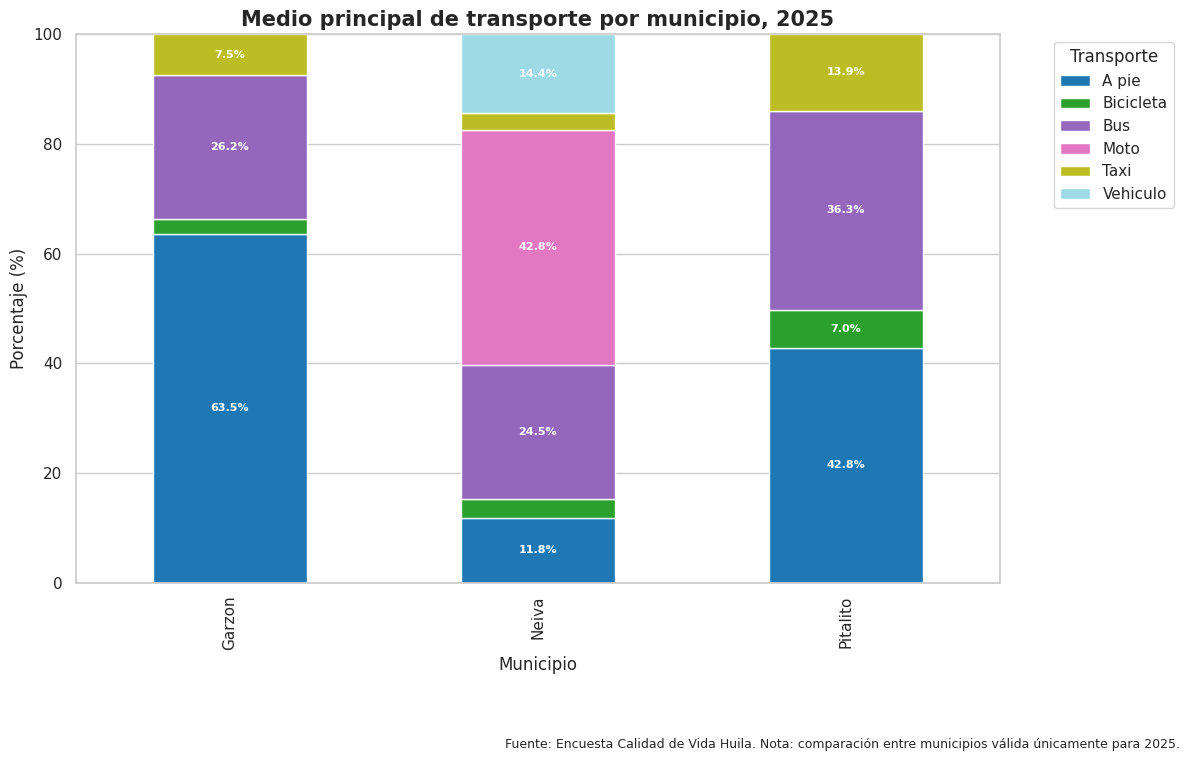


Satisfacción general por medio de transporte



,Grupo,Medio de transporte,n válido,Satisfechos,Insatisfechos,% satisfecho,% insatisfecho
0,Total,Bus,2375,1205,1170,50.74,49.26
1,Total,Taxi,1978,1044,934,52.78,47.22
2,Total,Vehiculo,2125,1564,561,73.60,26.40
3,Total,Moto,4059,3513,546,86.55,13.45
4,Total,A pie,2615,1629,986,62.29,37.71
5,Total,Bicicleta,1843,1021,822,55.40,44.60
6,Total,Otro transporte,0,0,0,No aplica,No aplica


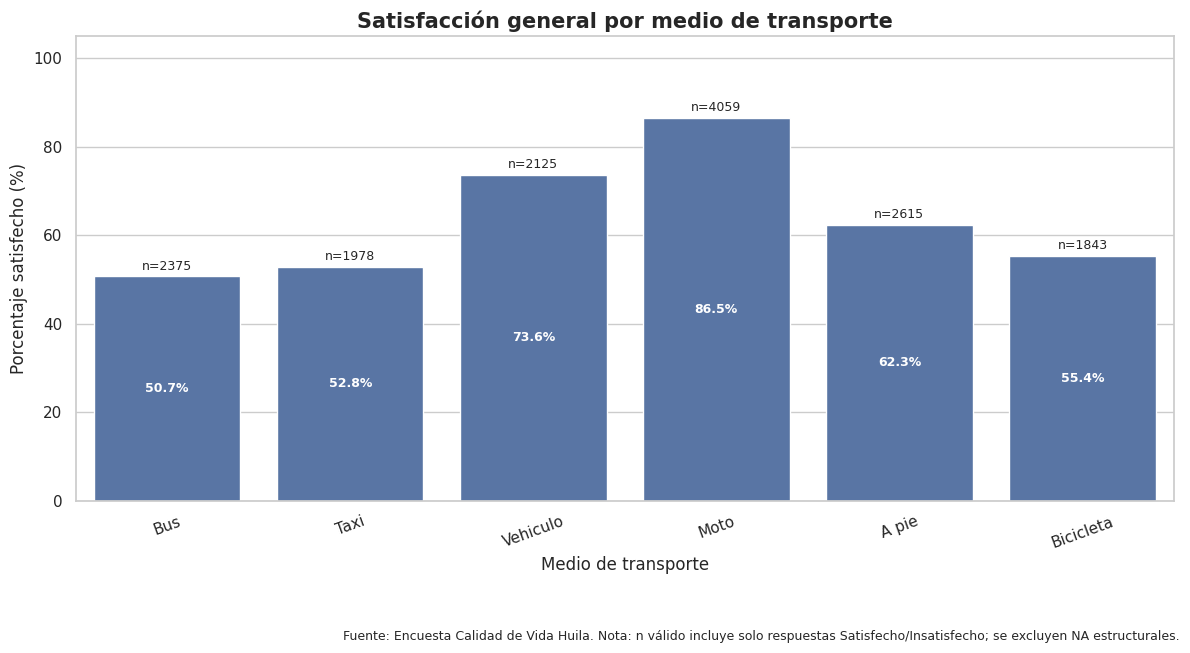


Satisfacción por medio de transporte y municipio, 2025



,Municipio,Medio de transporte,n válido,Satisfechos,Insatisfechos,% satisfecho,% insatisfecho
0,Garzon,Bus,28,18,10,64.29,35.71
1,Garzon,Taxi,8,6,2,75.00,25.00
2,Garzon,Vehiculo,0,0,0,No aplica,No aplica
3,Garzon,Moto,0,0,0,No aplica,No aplica
4,Garzon,A pie,68,30,38,44.12,55.88
5,Garzon,Bicicleta,3,3,0,100.00,0.00
6,Garzon,Otro transporte,0,0,0,No aplica,No aplica
7,Neiva,Bus,621,305,316,49.11,50.89
8,Neiva,Taxi,475,244,231,51.37,48.63
9,Neiva,Vehiculo,528,410,118,77.65,22.35


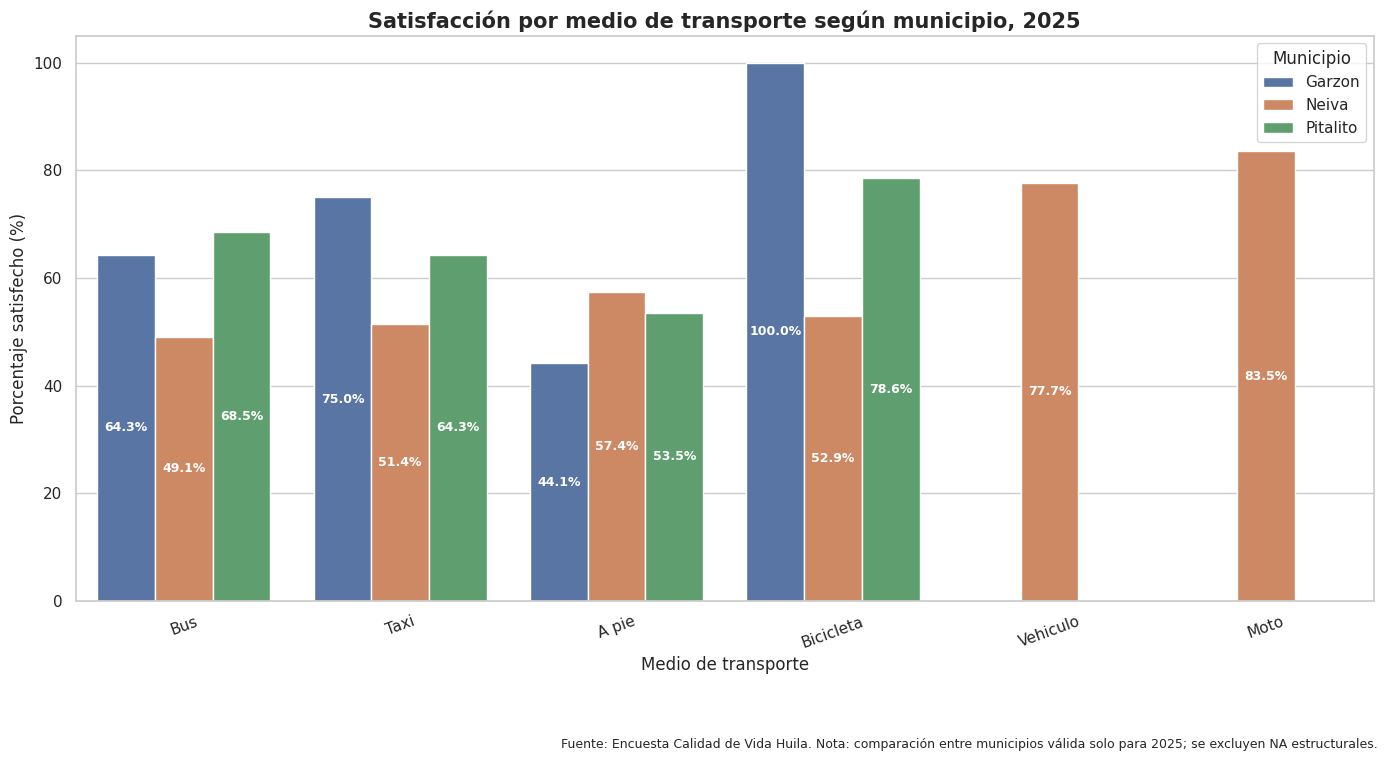


Garzón: satisfacción por medio de transporte, 2021-2025



,Año,Medio de transporte,n válido,Satisfechos,Insatisfechos,% satisfecho,% insatisfecho
0,2021,Bus,136,59,77,43.38,56.62
1,2021,Taxi,130,69,61,53.08,46.92
2,2021,Vehiculo,145,92,53,63.45,36.55
3,2021,Moto,297,262,35,88.22,11.78
4,2021,A pie,207,149,58,71.98,28.02
5,2021,Bicicleta,128,82,46,64.06,35.94
6,2021,Otro transporte,0,0,0,No aplica,No aplica
7,2022,Bus,400,211,189,52.75,47.25
8,2022,Taxi,381,201,180,52.76,47.24
9,2022,Vehiculo,411,305,106,74.21,25.79


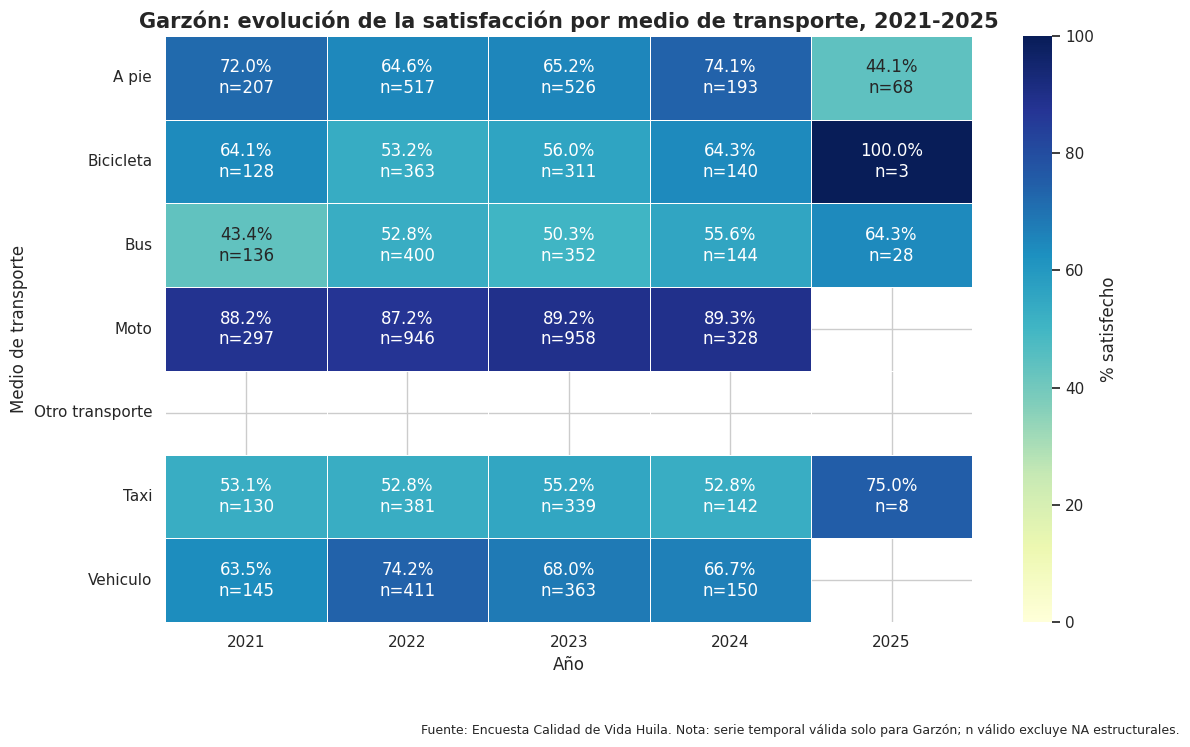


Garzón: medio principal de transporte por año - n


Transporte,A pie,Bicicleta,Bus,Moto,Taxi,Vehiculo
Año,,,,,,
2021,127,10,10,231,8,36
2022,226,11,57,783,30,95
2023,274,14,67,818,19,81
2024,94,7,16,260,4,28
2025,68,3,28,0,8,0



Garzón: medio principal de transporte por año - %


Transporte,A pie,Bicicleta,Bus,Moto,Taxi,Vehiculo
Año,,,,,,
2021,30.09,2.37,2.37,54.74,1.90,8.53
2022,18.80,0.92,4.74,65.14,2.50,7.90
2023,21.52,1.10,5.26,64.26,1.49,6.36
2024,22.98,1.71,3.91,63.57,0.98,6.85
2025,63.55,2.80,26.17,0.00,7.48,0.00


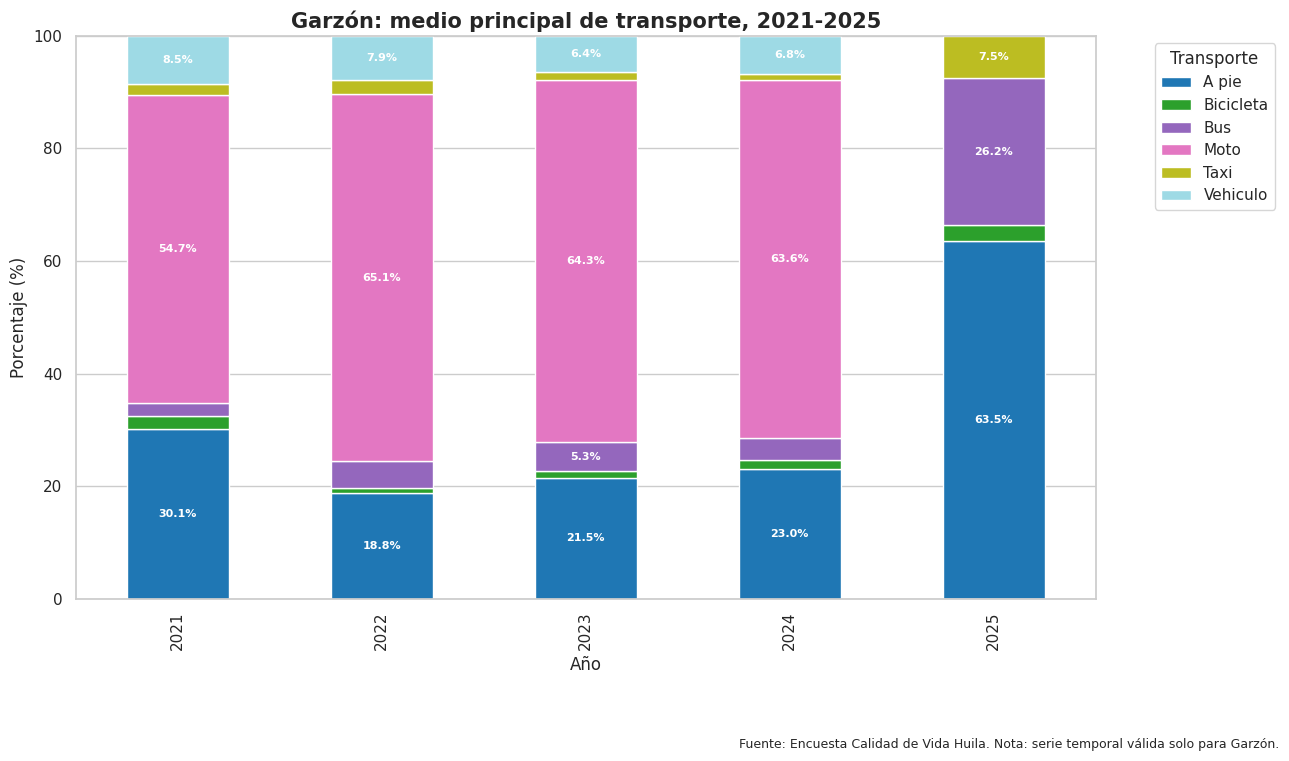


Neiva: satisfacción por medio de transporte, 2024-2025



,Año,Medio de transporte,n válido,Satisfechos,Insatisfechos,% satisfecho,% insatisfecho
0,2024,Bus,621,305,316,49.11,50.89
1,2024,Taxi,475,244,231,51.37,48.63
2,2024,Vehiculo,528,410,118,77.65,22.35
3,2024,Moto,765,639,126,83.53,16.47
4,2024,A pie,509,292,217,57.37,42.63
5,2024,Bicicleta,442,234,208,52.94,47.06
6,2024,Otro transporte,0,0,0,No aplica,No aplica
7,2025,Bus,621,305,316,49.11,50.89
8,2025,Taxi,475,244,231,51.37,48.63
9,2025,Vehiculo,528,410,118,77.65,22.35


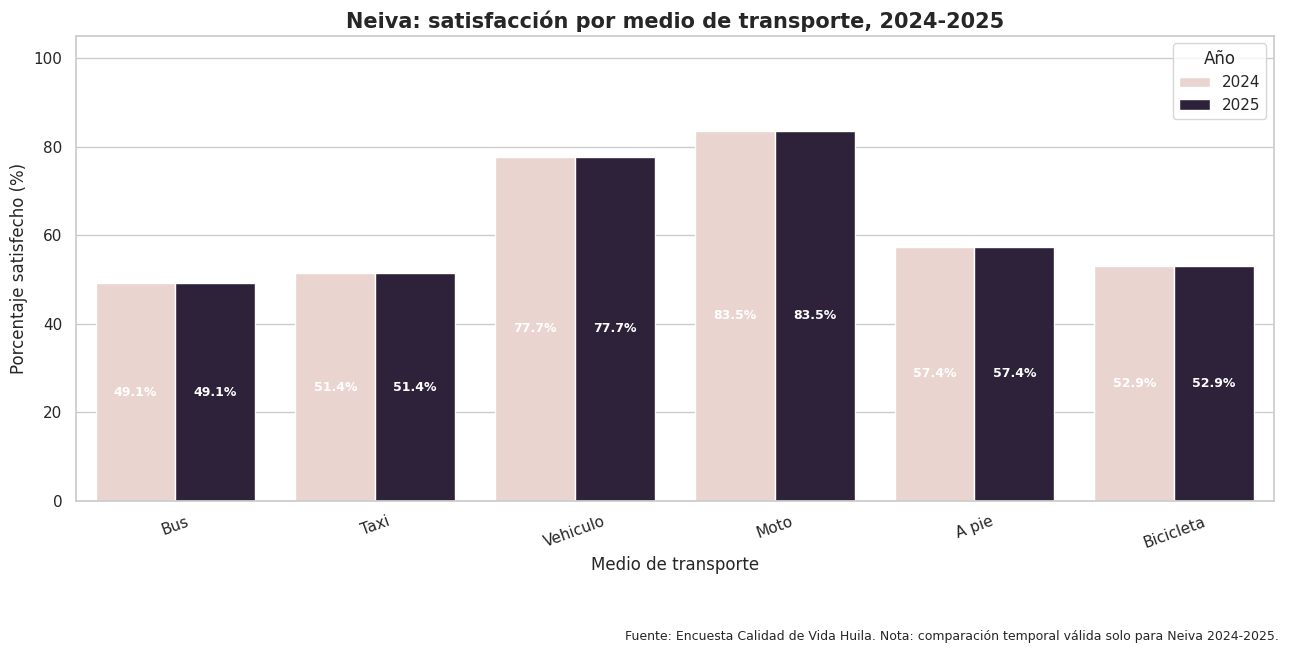


Medio principal de transporte por municipio, 2025 - n


Transporte,A pie,Bicicleta,Bus,Moto,Taxi,Vehiculo
Municipio,,,,,,
Garzon,68,3,28,0,8,0
Neiva,136,39,282,492,35,165
Pitalito,86,14,73,0,28,0



Medio principal de transporte por municipio, 2025 - %


Transporte,A pie,Bicicleta,Bus,Moto,Taxi,Vehiculo
Municipio,,,,,,
Garzon,63.55,2.80,26.17,0.00,7.48,0.00
Neiva,11.84,3.39,24.54,42.82,3.05,14.36
Pitalito,42.79,6.97,36.32,0.00,13.93,0.00


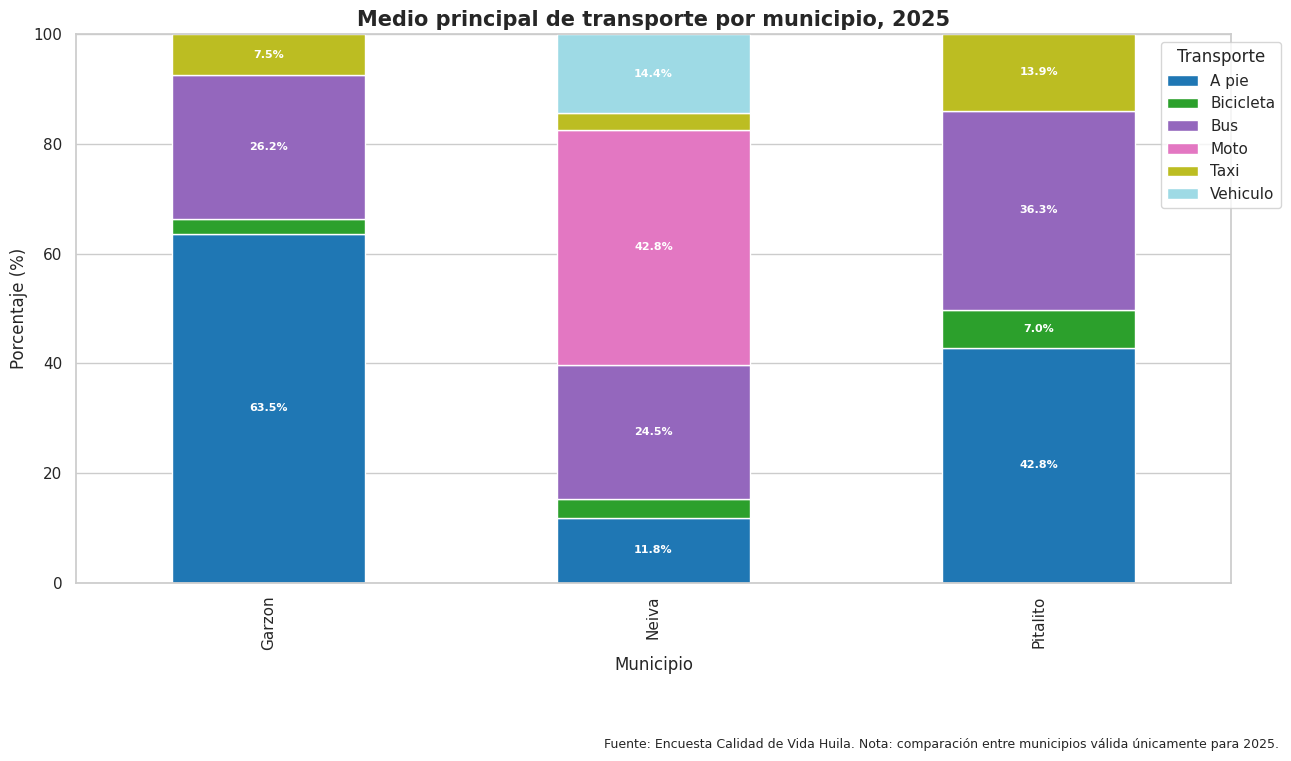


Nivel socioeconómico y medio principal de transporte, 2025 - n


Transporte,A pie,Bicicleta,Bus,Moto,Taxi,Vehiculo
Nivel socioeconomico,,,,,,
Alto,1,2,7,9,3,17
Bajo,156,31,179,145,15,19
Medio,133,23,197,338,53,129



Nivel socioeconómico y medio principal de transporte, 2025 - %


Transporte,A pie,Bicicleta,Bus,Moto,Taxi,Vehiculo
Nivel socioeconomico,,,,,,
Alto,2.56,5.13,17.95,23.08,7.69,43.59
Bajo,28.62,5.69,32.84,26.61,2.75,3.49
Medio,15.23,2.63,22.57,38.72,6.07,14.78


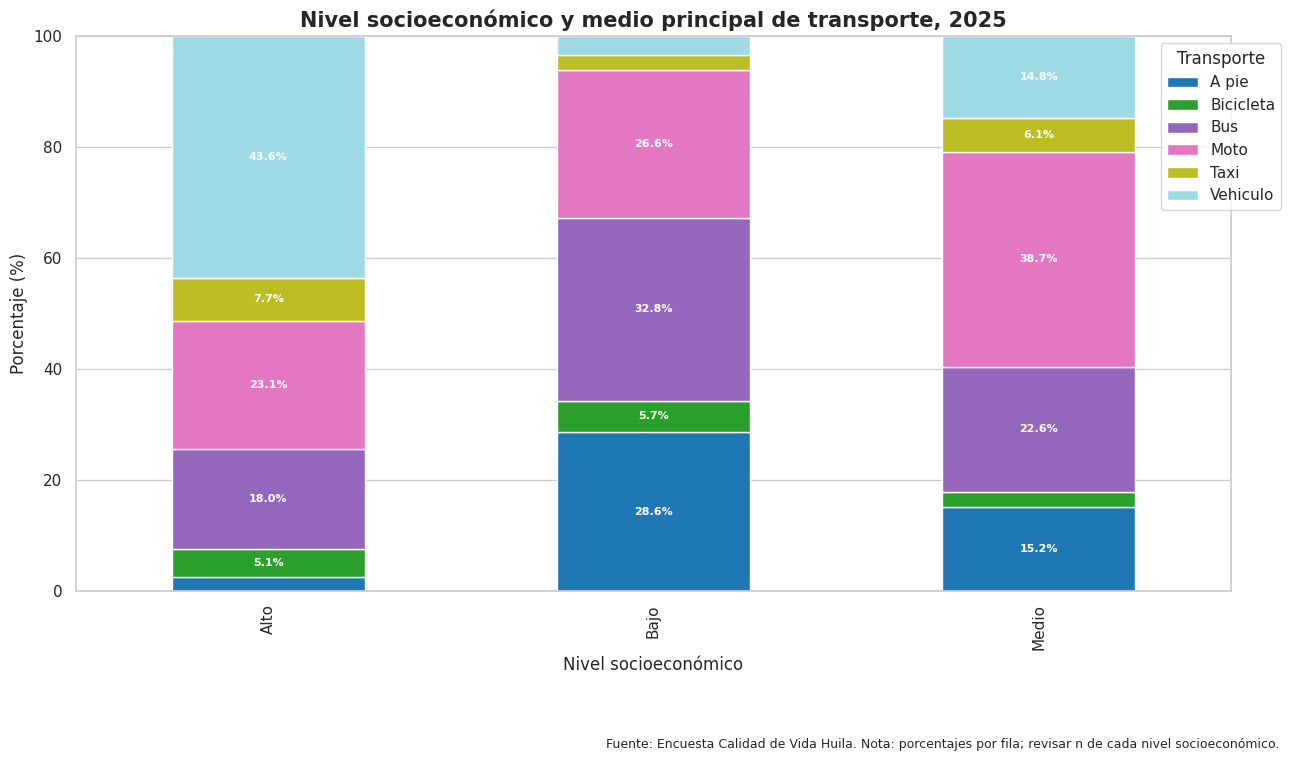

,Nivel socioeconomico,n,Advertencia
0,Medio,873,n suficiente para lectura descriptiva
1,Bajo,545,n suficiente para lectura descriptiva
2,Alto,39,n suficiente para lectura descriptiva



Sexo y medio principal de transporte, 2025 - n


Transporte,A pie,Bicicleta,Bus,Moto,Taxi,Vehiculo
Sexo,,,,,,
Femenino,183,16,241,245,43,84
Masculino,107,40,142,247,28,81



Sexo y medio principal de transporte, 2025 - %


Transporte,A pie,Bicicleta,Bus,Moto,Taxi,Vehiculo
Sexo,,,,,,
Femenino,22.54,1.97,29.68,30.17,5.30,10.34
Masculino,16.59,6.20,22.02,38.29,4.34,12.56


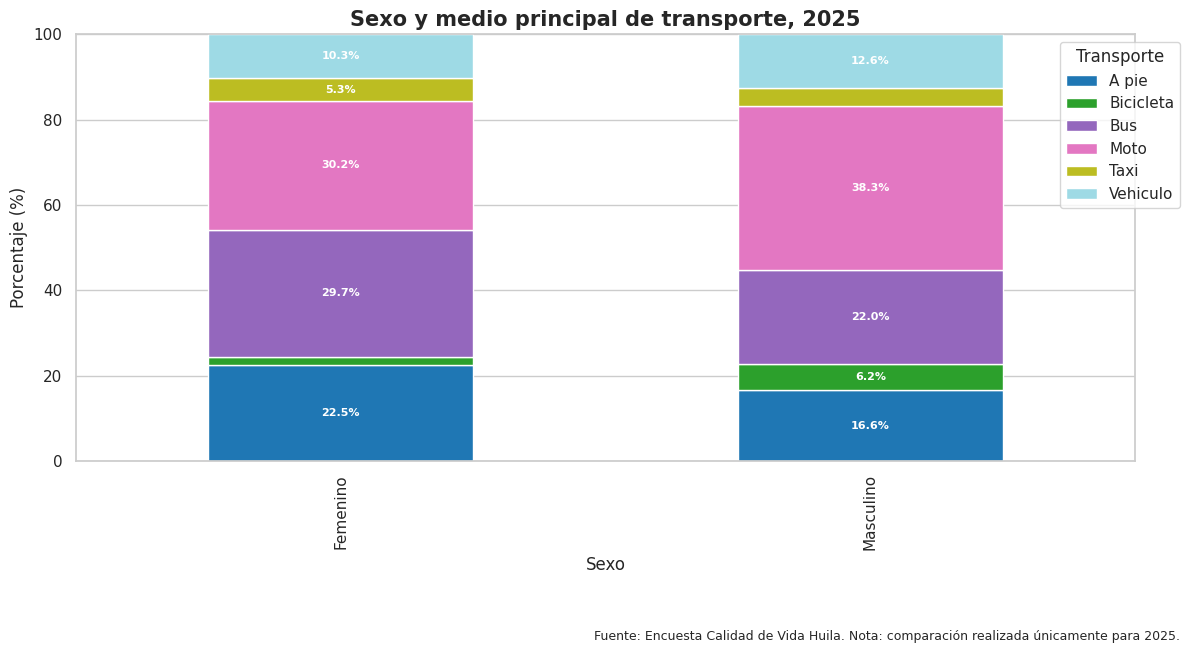


Grupo de edad y medio principal de transporte, 2025 - n


Transporte,A pie,Bicicleta,Bus,Moto,Taxi,Vehiculo
Grupo edad,,,,,,
18-25,182,35,255,281,42,76
26-35,50,10,54,108,9,23
36-45,23,5,28,58,9,24
46-60,24,3,30,41,7,30
61 o más,11,3,16,4,4,12



Grupo de edad y medio principal de transporte, 2025 - %


Transporte,A pie,Bicicleta,Bus,Moto,Taxi,Vehiculo
Grupo edad,,,,,,
18-25,20.90,4.02,29.28,32.26,4.82,8.73
26-35,19.69,3.94,21.26,42.52,3.54,9.06
36-45,15.65,3.40,19.05,39.46,6.12,16.33
46-60,17.78,2.22,22.22,30.37,5.19,22.22
61 o más,22.00,6.00,32.00,8.00,8.00,24.00


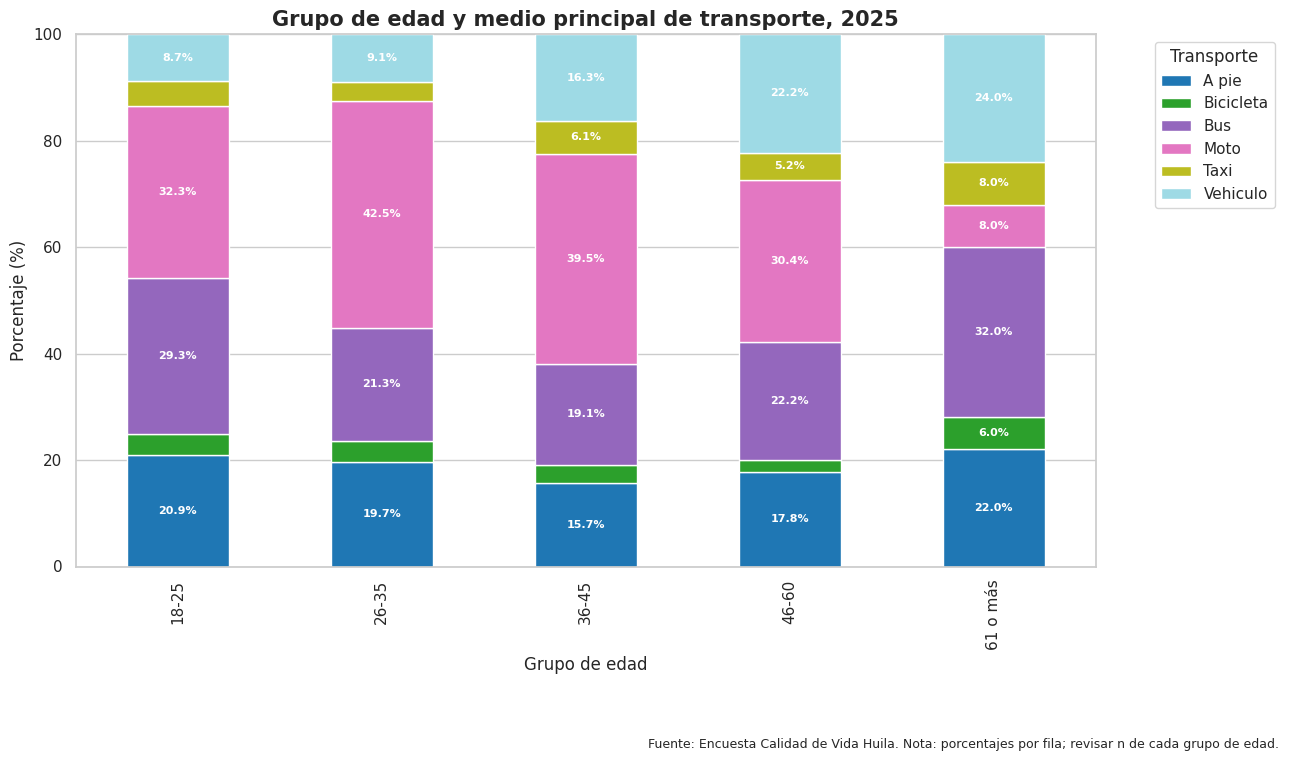

Archivo exportado: tablas_movilidad/tablas_resultados_movilidad_huila.xlsx
Gráficos guardados en la carpeta: graficos_movilidad


In [20]:
# =========================================================
# 15. ESTRUCTURA DEL PANEL DESBALANCEADO
# =========================================================

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs("graficos_movilidad", exist_ok=True)
os.makedirs("tablas_movilidad", exist_ok=True)

print("\n=================================================")
print("ESTRUCTURA DEL PANEL POR MUNICIPIO Y AÑO")
print("=================================================\n")

panel = (
    df.groupby(["Municipio", "Año"])
    .size()
    .reset_index(name="n")
)

print(panel)

print("""
Nota metodológica:
El panel es desbalanceado. Para el tema de movilidad:
- Garzón permite análisis temporal 2021-2025.
- Neiva solo permite comparación 2024-2025.
- Pitalito solo tiene información para 2025.
- Las comparaciones entre municipios se hacen únicamente para 2025.
""")

df_2025 = df[df["Año"] == 2025].copy()
df_garzon = df[df["Municipio"].astype(str).str.contains("Garzon|Garzón", case=False, na=False)].copy()
df_neiva = df[df["Municipio"].astype(str).str.contains("Neiva", case=False, na=False)].copy()
df_pitalito = df[df["Municipio"].astype(str).str.contains("Pitalito", case=False, na=False)].copy()


# =========================================================
# 16. VARIABLES DE MOVILIDAD
# =========================================================

variables_transporte = [
    "Bus",
    "Taxi",
    "Vehiculo",
    "Moto",
    "A pie",
    "Bicicleta",
    "Otro transporte"
]


# =========================================================
# FUNCIONES AUXILIARES PARA ETIQUETAS EN GRÁFICOS
# =========================================================

def agregar_etiquetas_barras(ax, minimo=3):
    """
    Agrega porcentajes dentro de barras agrupadas.
    Se omiten porcentajes pequeños para evitar sobreposición visual.
    """

    for contenedor in ax.containers:
        etiquetas = []

        for barra in contenedor:
            alto = barra.get_height()

            if pd.isna(alto) or alto < minimo:
                etiquetas.append("")
            else:
                etiquetas.append(f"{alto:.1f}%")

        ax.bar_label(
            contenedor,
            labels=etiquetas,
            label_type="center",
            fontsize=9,
            color="white",
            fontweight="bold"
        )


def agregar_etiquetas_apiladas(ax, minimo=5):
    """
    Agrega porcentajes dentro de barras apiladas.
    Se omiten segmentos pequeños para evitar saturación.
    """

    for contenedor in ax.containers:
        etiquetas = []

        for valor in contenedor.datavalues:
            if pd.isna(valor) or valor < minimo:
                etiquetas.append("")
            else:
                etiquetas.append(f"{valor:.1f}%")

        ax.bar_label(
            contenedor,
            labels=etiquetas,
            label_type="center",
            fontsize=8,
            color="white",
            fontweight="bold"
        )


# =========================================================
# 17. SATISFACCIÓN GENERAL POR MEDIO DE TRANSPORTE
# =========================================================

resumen_satisfaccion = []

for var in variables_transporte:
    n_valido = df[var].notna().sum()
    satisfechos = (df[var] == "Satisfecho").sum()
    insatisfechos = (df[var] == "Insatisfecho").sum()

    pct_satisfecho = round(satisfechos / n_valido * 100, 2) if n_valido > 0 else np.nan
    pct_insatisfecho = round(insatisfechos / n_valido * 100, 2) if n_valido > 0 else np.nan

    resumen_satisfaccion.append({
        "Medio de transporte": var,
        "n válido": n_valido,
        "Satisfechos": satisfechos,
        "Insatisfechos": insatisfechos,
        "% satisfecho": pct_satisfecho,
        "% insatisfecho": pct_insatisfecho,
        "Denominador": "Personas que sí calificaron el medio"
    })

tabla_satisfaccion = pd.DataFrame(resumen_satisfaccion)

print("\n=================================================")
print("SATISFACCIÓN GENERAL POR MEDIO DE TRANSPORTE")
print("=================================================\n")
print(tabla_satisfaccion)

plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=tabla_satisfaccion,
    x="Medio de transporte",
    y="% satisfecho"
)

agregar_etiquetas_barras(ax, minimo=3)

plt.title("Satisfacción general por medio de transporte", fontsize=15, fontweight="bold")
plt.xlabel("Medio de transporte")
plt.ylabel("Porcentaje satisfecho (%)")
plt.ylim(0,105)
plt.xticks(rotation=20)

for i, row in tabla_satisfaccion.reset_index(drop=True).iterrows():
    if not pd.isna(row["% satisfecho"]):
        plt.text(
            i,
            row["% satisfecho"] + 1.5,
            f'n={int(row["n válido"])}',
            ha="center",
            fontsize=9
        )

plt.figtext(
    0.99,
    -0.07,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: se excluyen NA estructurales; el denominador son quienes sí calificaron cada medio.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.show()


# =========================================================
# 18. MEDIO PRINCIPAL DE TRANSPORTE, SOLO 2025
# =========================================================

transporte_2025_n = pd.crosstab(
    df_2025["Municipio"],
    df_2025["Transporte"]
)

transporte_2025_pct = round(
    pd.crosstab(
        df_2025["Municipio"],
        df_2025["Transporte"],
        normalize="index"
    ) * 100,
    2
)

print("\n=================================================")
print("MEDIO PRINCIPAL DE TRANSPORTE POR MUNICIPIO, 2025 - n")
print("=================================================\n")
print(transporte_2025_n)

print("\n=================================================")
print("MEDIO PRINCIPAL DE TRANSPORTE POR MUNICIPIO, 2025 - %")
print("=================================================\n")
print(transporte_2025_pct)

ax = transporte_2025_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7),
    colormap="tab20"
)

agregar_etiquetas_apiladas(ax, minimo=5)

plt.title("Medio principal de transporte por municipio, 2025", fontsize=15, fontweight="bold")
plt.xlabel("Municipio")
plt.ylabel("Porcentaje (%)")
plt.ylim(0,100)
plt.legend(title="Transporte", bbox_to_anchor=(1.05,1))

plt.figtext(
    0.99,
    -0.08,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: comparación entre municipios válida únicamente para 2025.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.show()


# =========================================================
# 19. FUNCIONES PARA TABLAS Y GRÁFICOS DE PRESENTACIÓN
# =========================================================

def resumen_satisfaccion_por_grupo(data, grupo=None):
    """
    Calcula satisfacción e insatisfacción por medio de transporte.
    El n válido SOLO cuenta respuestas válidas: Satisfecho o Insatisfecho.
    No cuenta NA ni otras categorías como No aplica.
    """

    resultados = []

    if grupo is None:
        grupos = [("Total", data)]
        nombre_grupo = "Grupo"
    else:
        grupos = list(data.groupby(grupo))
        nombre_grupo = grupo

    for valor_grupo, temp in grupos:
        for medio in variables_transporte:

            respuestas_validas = temp[temp[medio].isin(["Satisfecho", "Insatisfecho"])]

            n_valido = len(respuestas_validas)
            satisfechos = (respuestas_validas[medio] == "Satisfecho").sum()
            insatisfechos = (respuestas_validas[medio] == "Insatisfecho").sum()

            pct_satisfecho = round(satisfechos / n_valido * 100, 2) if n_valido > 0 else np.nan
            pct_insatisfecho = round(insatisfechos / n_valido * 100, 2) if n_valido > 0 else np.nan

            resultados.append({
                nombre_grupo: valor_grupo,
                "Medio de transporte": medio,
                "n válido": n_valido,
                "Satisfechos": satisfechos,
                "Insatisfechos": insatisfechos,
                "% satisfecho": pct_satisfecho,
                "% insatisfecho": pct_insatisfecho
            })

    return pd.DataFrame(resultados)


def mostrar_tabla_bonita(tabla, titulo):
    print("\n" + "="*70)
    print(titulo)
    print("="*70 + "\n")

    display(
        tabla.style
        .format({
            "% satisfecho": "{:.2f}",
            "% insatisfecho": "{:.2f}"
        }, na_rep="No aplica")
        .set_caption(titulo)
        .background_gradient(subset=["% satisfecho"], cmap="Greens")
        .background_gradient(subset=["% insatisfecho"], cmap="Reds")
    )


# =========================================================
# 20. SATISFACCIÓN GENERAL POR MEDIO DE TRANSPORTE
# =========================================================

tabla_satisfaccion_general = resumen_satisfaccion_por_grupo(df)

mostrar_tabla_bonita(
    tabla_satisfaccion_general,
    "Satisfacción general por medio de transporte"
)

tabla_plot = tabla_satisfaccion_general[
    tabla_satisfaccion_general["n válido"] > 0
].copy()

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=tabla_plot,
    x="Medio de transporte",
    y="% satisfecho"
)

agregar_etiquetas_barras(ax, minimo=3)

plt.title("Satisfacción general por medio de transporte", fontsize=15, fontweight="bold")
plt.xlabel("Medio de transporte")
plt.ylabel("Porcentaje satisfecho (%)")
plt.ylim(0,105)
plt.xticks(rotation=20)

for i, row in tabla_plot.reset_index(drop=True).iterrows():
    plt.text(
        i,
        row["% satisfecho"] + 1.5,
        f'n={int(row["n válido"])}',
        ha="center",
        fontsize=9
    )

plt.figtext(
    0.99,
    -0.08,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: n válido incluye solo respuestas Satisfecho/Insatisfecho; se excluyen NA estructurales.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.savefig("graficos_movilidad/satisfaccion_general_transporte.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 21. SATISFACCIÓN POR MUNICIPIO Y MEDIO DE TRANSPORTE, SOLO 2025
# =========================================================

tabla_municipio_transporte = resumen_satisfaccion_por_grupo(
    data=df_2025,
    grupo="Municipio"
)

mostrar_tabla_bonita(
    tabla_municipio_transporte,
    "Satisfacción por medio de transporte y municipio, 2025"
)

tabla_municipio_plot = tabla_municipio_transporte[
    tabla_municipio_transporte["n válido"] > 0
].copy()

plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=tabla_municipio_plot,
    x="Medio de transporte",
    y="% satisfecho",
    hue="Municipio"
)

agregar_etiquetas_barras(ax, minimo=3)

plt.title("Satisfacción por medio de transporte según municipio, 2025", fontsize=15, fontweight="bold")
plt.xlabel("Medio de transporte")
plt.ylabel("Porcentaje satisfecho (%)")
plt.ylim(0,105)
plt.xticks(rotation=20)
plt.legend(title="Municipio")

plt.figtext(
    0.99,
    -0.08,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: comparación entre municipios válida solo para 2025; se excluyen NA estructurales.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.savefig("graficos_movilidad/satisfaccion_municipio_transporte_2025.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 22. GARZÓN: EVOLUCIÓN TEMPORAL DE SATISFACCIÓN POR TRANSPORTE
# =========================================================

tabla_garzon_satisfaccion = resumen_satisfaccion_por_grupo(
    data=df_garzon,
    grupo="Año"
)

mostrar_tabla_bonita(
    tabla_garzon_satisfaccion,
    "Garzón: satisfacción por medio de transporte, 2021-2025"
)

garzon_heatmap = tabla_garzon_satisfaccion.pivot(
    index="Medio de transporte",
    columns="Año",
    values="% satisfecho"
)

garzon_n = tabla_garzon_satisfaccion.pivot(
    index="Medio de transporte",
    columns="Año",
    values="n válido"
)

anotaciones = garzon_heatmap.copy().astype(object)

for i in garzon_heatmap.index:
    for j in garzon_heatmap.columns:
        pct = garzon_heatmap.loc[i, j]
        n = garzon_n.loc[i, j]

        if pd.isna(pct) or n == 0:
            anotaciones.loc[i, j] = "No aplica"
        else:
            anotaciones.loc[i, j] = f"{pct:.1f}%\nn={int(n)}"

plt.figure(figsize=(12,7))

sns.heatmap(
    garzon_heatmap,
    annot=anotaciones,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% satisfecho"}
)

plt.title("Garzón: evolución de la satisfacción por medio de transporte, 2021-2025", fontsize=15, fontweight="bold")
plt.xlabel("Año")
plt.ylabel("Medio de transporte")

plt.figtext(
    0.99,
    -0.06,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: serie temporal válida solo para Garzón; n válido excluye NA estructurales.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.savefig("graficos_movilidad/garzon_satisfaccion_transporte_2021_2025.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 23. GARZÓN: MEDIO PRINCIPAL DE TRANSPORTE POR AÑO
# =========================================================

garzon_transporte_n = pd.crosstab(
    df_garzon["Año"],
    df_garzon["Transporte"]
)

garzon_transporte_pct = round(
    pd.crosstab(
        df_garzon["Año"],
        df_garzon["Transporte"],
        normalize="index"
    ) * 100,
    2
)

print("\nGarzón: medio principal de transporte por año - n")
display(garzon_transporte_n)

print("\nGarzón: medio principal de transporte por año - %")
display(garzon_transporte_pct)

ax = garzon_transporte_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(13,7),
    colormap="tab20"
)

agregar_etiquetas_apiladas(ax, minimo=5)

plt.title("Garzón: medio principal de transporte, 2021-2025", fontsize=15, fontweight="bold")
plt.xlabel("Año")
plt.ylabel("Porcentaje (%)")
plt.ylim(0,100)
plt.legend(title="Transporte", bbox_to_anchor=(1.05,1))

plt.figtext(
    0.99,
    -0.08,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: serie temporal válida solo para Garzón.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.savefig("graficos_movilidad/garzon_medio_principal_transporte_2021_2025.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 24. NEIVA: SATISFACCIÓN POR TRANSPORTE, 2024-2025
# =========================================================

tabla_neiva_satisfaccion = resumen_satisfaccion_por_grupo(
    data=df_neiva,
    grupo="Año"
)

mostrar_tabla_bonita(
    tabla_neiva_satisfaccion,
    "Neiva: satisfacción por medio de transporte, 2024-2025"
)

tabla_neiva_plot = tabla_neiva_satisfaccion[
    tabla_neiva_satisfaccion["n válido"] > 0
].copy()

plt.figure(figsize=(13,6))

ax = sns.barplot(
    data=tabla_neiva_plot,
    x="Medio de transporte",
    y="% satisfecho",
    hue="Año"
)

agregar_etiquetas_barras(ax, minimo=3)

plt.title("Neiva: satisfacción por medio de transporte, 2024-2025", fontsize=15, fontweight="bold")
plt.xlabel("Medio de transporte")
plt.ylabel("Porcentaje satisfecho (%)")
plt.ylim(0,105)
plt.xticks(rotation=20)
plt.legend(title="Año")

plt.figtext(
    0.99,
    -0.08,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: comparación temporal válida solo para Neiva 2024-2025.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.savefig("graficos_movilidad/neiva_satisfaccion_transporte_2024_2025.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 25. MEDIO PRINCIPAL DE TRANSPORTE POR MUNICIPIO, 2025
# =========================================================

transporte_2025_n = pd.crosstab(
    df_2025["Municipio"],
    df_2025["Transporte"]
)

transporte_2025_pct = round(
    pd.crosstab(
        df_2025["Municipio"],
        df_2025["Transporte"],
        normalize="index"
    ) * 100,
    2
)

print("\nMedio principal de transporte por municipio, 2025 - n")
display(transporte_2025_n)

print("\nMedio principal de transporte por municipio, 2025 - %")
display(transporte_2025_pct)

ax = transporte_2025_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(13,7),
    colormap="tab20"
)

agregar_etiquetas_apiladas(ax, minimo=5)

plt.title("Medio principal de transporte por municipio, 2025", fontsize=15, fontweight="bold")
plt.xlabel("Municipio")
plt.ylabel("Porcentaje (%)")
plt.ylim(0,100)
plt.legend(title="Transporte", bbox_to_anchor=(1.05,1))

plt.figtext(
    0.99,
    -0.08,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: comparación entre municipios válida únicamente para 2025.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.savefig("graficos_movilidad/medio_principal_transporte_municipio_2025.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 26. CRUCE BIVARIADO: NIVEL SOCIOECONÓMICO Y TRANSPORTE, 2025
# =========================================================

nivel_transporte_n = pd.crosstab(
    df_2025["Nivel socioeconomico"],
    df_2025["Transporte"]
)

nivel_transporte_pct = round(
    pd.crosstab(
        df_2025["Nivel socioeconomico"],
        df_2025["Transporte"],
        normalize="index"
    ) * 100,
    2
)

print("\nNivel socioeconómico y medio principal de transporte, 2025 - n")
display(nivel_transporte_n)

print("\nNivel socioeconómico y medio principal de transporte, 2025 - %")
display(nivel_transporte_pct)

ax = nivel_transporte_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(13,7),
    colormap="tab20"
)

agregar_etiquetas_apiladas(ax, minimo=5)

plt.title("Nivel socioeconómico y medio principal de transporte, 2025", fontsize=15, fontweight="bold")
plt.xlabel("Nivel socioeconómico")
plt.ylabel("Porcentaje (%)")
plt.ylim(0,100)
plt.legend(title="Transporte", bbox_to_anchor=(1.05,1))

plt.figtext(
    0.99,
    -0.08,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: porcentajes por fila; revisar n de cada nivel socioeconómico.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.savefig("graficos_movilidad/nivel_socioeconomico_transporte_2025.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 27. ALERTA DE SUBGRUPOS PEQUEÑOS
# =========================================================

n_nivel_2025 = (
    df_2025["Nivel socioeconomico"]
    .value_counts()
    .reset_index()
)

n_nivel_2025.columns = ["Nivel socioeconomico", "n"]

n_nivel_2025["Advertencia"] = np.where(
    n_nivel_2025["n"] < 30,
    "Precaución: subgrupo pequeño",
    "n suficiente para lectura descriptiva"
)

display(n_nivel_2025)


# =========================================================
# 28. CRUCE BIVARIADO: SEXO Y MEDIO PRINCIPAL DE TRANSPORTE, 2025
# =========================================================

sexo_transporte_n = pd.crosstab(
    df_2025["Sexo"],
    df_2025["Transporte"]
)

sexo_transporte_pct = round(
    pd.crosstab(
        df_2025["Sexo"],
        df_2025["Transporte"],
        normalize="index"
    ) * 100,
    2
)

print("\nSexo y medio principal de transporte, 2025 - n")
display(sexo_transporte_n)

print("\nSexo y medio principal de transporte, 2025 - %")
display(sexo_transporte_pct)

ax = sexo_transporte_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="tab20"
)

agregar_etiquetas_apiladas(ax, minimo=5)

plt.title("Sexo y medio principal de transporte, 2025", fontsize=15, fontweight="bold")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje (%)")
plt.ylim(0,100)
plt.legend(title="Transporte", bbox_to_anchor=(1.05,1))

plt.figtext(
    0.99,
    -0.08,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: comparación realizada únicamente para 2025.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.savefig("graficos_movilidad/sexo_transporte_2025.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 29. EDAD Y MEDIO PRINCIPAL DE TRANSPORTE, 2025
# =========================================================

df_2025["Grupo edad"] = pd.cut(
    df_2025["Edad"],
    bins=[17, 25, 35, 45, 60, 99],
    labels=["18-25", "26-35", "36-45", "46-60", "61 o más"]
)

edad_transporte_n = pd.crosstab(
    df_2025["Grupo edad"],
    df_2025["Transporte"]
)

edad_transporte_pct = round(
    pd.crosstab(
        df_2025["Grupo edad"],
        df_2025["Transporte"],
        normalize="index"
    ) * 100,
    2
)

print("\nGrupo de edad y medio principal de transporte, 2025 - n")
display(edad_transporte_n)

print("\nGrupo de edad y medio principal de transporte, 2025 - %")
display(edad_transporte_pct)

ax = edad_transporte_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(13,7),
    colormap="tab20"
)

agregar_etiquetas_apiladas(ax, minimo=5)

plt.title("Grupo de edad y medio principal de transporte, 2025", fontsize=15, fontweight="bold")
plt.xlabel("Grupo de edad")
plt.ylabel("Porcentaje (%)")
plt.ylim(0,100)
plt.legend(title="Transporte", bbox_to_anchor=(1.05,1))

plt.figtext(
    0.99,
    -0.08,
    "Fuente: Encuesta Calidad de Vida Huila. Nota: porcentajes por fila; revisar n de cada grupo de edad.",
    horizontalalignment="right",
    fontsize=9
)

plt.tight_layout()
plt.savefig("graficos_movilidad/edad_transporte_2025.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 30. EXPORTAR TABLAS A EXCEL
# =========================================================

with pd.ExcelWriter("tablas_movilidad/tablas_resultados_movilidad_huila.xlsx") as writer:
    tabla_satisfaccion_general.to_excel(writer, sheet_name="Satisfaccion general", index=False)
    tabla_municipio_transporte.to_excel(writer, sheet_name="Satisfaccion mpio 2025", index=False)
    tabla_garzon_satisfaccion.to_excel(writer, sheet_name="Garzon satisfaccion", index=False)
    tabla_neiva_satisfaccion.to_excel(writer, sheet_name="Neiva satisfaccion", index=False)
    transporte_2025_n.to_excel(writer, sheet_name="Transporte mpio n")
    transporte_2025_pct.to_excel(writer, sheet_name="Transporte mpio pct")
    garzon_transporte_n.to_excel(writer, sheet_name="Garzon transporte n")
    garzon_transporte_pct.to_excel(writer, sheet_name="Garzon transporte pct")
    nivel_transporte_n.to_excel(writer, sheet_name="Nivel transporte n")
    nivel_transporte_pct.to_excel(writer, sheet_name="Nivel transporte pct")
    sexo_transporte_n.to_excel(writer, sheet_name="Sexo transporte n")
    sexo_transporte_pct.to_excel(writer, sheet_name="Sexo transporte pct")
    edad_transporte_n.to_excel(writer, sheet_name="Edad transporte n")
    edad_transporte_pct.to_excel(writer, sheet_name="Edad transporte pct")
    n_nivel_2025.to_excel(writer, sheet_name="Alerta subgrupos", index=False)

print("Archivo exportado: tablas_movilidad/tablas_resultados_movilidad_huila.xlsx")
print("Gráficos guardados en la carpeta: graficos_movilidad")